In [ ]:
# std_name: Mojtaba Hashenbeigi
# std_id : 4043614036

In [ ]:
# آماده‌سازی محیط، اتصال به درایو و دانلود مدل

In [ ]:

import os
from google.colab import drive

# ۱. اتصال به گوگل درایو
drive.mount('/content/drive')

project_path = '/content/drive/My Drive/DIP_FinalProject'
video_path = os.path.join(project_path, 'Eagle.mp4')

if not os.path.exists(project_path):
    os.makedirs(project_path)
    print(f"پوشه ایجاد شد: {project_path}")

if not os.path.exists(video_path):
    print(" خطا: فایل Eagle.mp4 در درایو یافت نشد. لطفاً آن را آپلود کنید.")
else:
    print(" فایل ویدیویی با موفقیت یافت شد.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ فایل ویدیویی با موفقیت یافت شد.


In [ ]:
# . کلون کردن مخزن و نصب پیش‌نیازها
!git clone https://github.com/facebookresearch/sam3.git
%cd sam3
!pip install -e .
!pip install opencv-python matplotlib numpy torch torchvision

Cloning into 'sam3'...
remote: Enumerating objects: 1187, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 1187 (delta 1), reused 3 (delta 1), pack-reused 1178 (from 2)
Receiving objects: 100% (1187/1187), 60.37 MiB | 18.62 MiB/s, done.
Resolving deltas: 100% (346/346), done.
/content/sam3
Obtaining file:///content/sam3
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.1/53.1 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 83.3 MB/s eta 0:00:00
  Building editable for sam3 (pyproject.toml) ... 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 103.9 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sam3 0.1.0 requires numpy<2,>=1.26, but you have numpy 2.5.1 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.5.1 which is incompatible.


In [ ]:


#  دانلود وزن‌های مدل SAM 3 با aria2
!apt-get -qq install -y aria2
URL = "https://huggingface.co/bodhicitta/sam3/resolve/main/sam3.pt"
!aria2c -x 16 -s 16 -k 1M -c --file-allocation=none -o sam3.pt -d /content "{URL}"

CHECKPOINT_PATH = "/content/sam3.pt"
size_gb = os.path.getsize(CHECKPOINT_PATH) / 1e9
print(f" مدل دانلود شد: {size_gb:.2f} GB")
assert size_gb > 3.3, "خطا در دانلود مدل، لطفاً دوباره تلاش کنید."

Selecting previously unselected package libc-ares2:amd64.
(Reading database ... 122403 files and directories currently installed.)
Preparing to unpack .../libc-ares2_1.18.1-1ubuntu0.22.04.3_amd64.deb ...
Unpacking libc-ares2:amd64 (1.18.1-1ubuntu0.22.04.3) ...
Selecting previously unselected package libaria2-0:amd64.
Preparing to unpack .../libaria2-0_1.36.0-1_amd64.deb ...
Unpacking libaria2-0:amd64 (1.36.0-1) ...
Selecting previously unselected package aria2.
Preparing to unpack .../aria2_1.36.0-1_amd64.deb ...
Unpacking aria2 (1.36.0-1) ...
Setting up libc-ares2:amd64 (1.18.1-1ubuntu0.22.04.3) ...
Setting up libaria2-0:amd64 (1.36.0-1) ...
Setting up aria2 (1.36.0-1) ...
Processing triggers for man-db (2.10.2-1) ...
Processing triggers for libc-bin (2.35-0ubuntu3.8) ...
/sbin/ldconfig.real: /usr/local/lib/libtbbbind_2_0.so.3 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libur_loader.so.0 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libhwloc.so.15 is not 

In [ ]:
!pip install triton einops ninja

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 12.9 MB/s eta 0:00:00


In [ ]:
# ردیابی ویدیویی و تولید خروجی

In [ ]:

import os
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
import huggingface_hub

if os.path.exists('/content/sam3'):
    os.chdir('/content/sam3')

CHECKPOINT_PATH = "/content/sam3.pt"

if getattr(huggingface_hub.hf_hub_download, '__name__', '') != 'smart_hf_download':
    original_hf_download = huggingface_hub.hf_hub_download

    def smart_hf_download(*args, **kwargs):

        if 'repo_id' in kwargs and kwargs['repo_id'] == 'facebook/sam3':
            kwargs['repo_id'] = 'bodhicitta/sam3'
        elif len(args) > 0 and args[0] == 'facebook/sam3':
            args = ('bodhicitta/sam3',) + args[1:]

        filename = kwargs.get('filename', '')
        if not filename and len(args) > 1:
            filename = args[1]

        if 'sam3.pt' in str(filename):
            return CHECKPOINT_PATH

        return original_hf_download(*args, **kwargs)

    huggingface_hub.hf_hub_download = smart_hf_download

if getattr(os.path.dirname, '__name__', '') != 'safe_dirname':
    original_dirname = os.path.dirname
    def safe_dirname(p):
        if p is None:
            return "/content/sam3"
        return original_dirname(p)
    os.path.dirname = safe_dirname
# --------------------------------------------------------

from sam3.model_builder import build_sam3_video_predictor

video_path = '/content/drive/My Drive/DIP_FinalProject/Eagle.mp4'
output_video_path = '/content/drive/My Drive/DIP_FinalProject/Eagle_tracked.mp4'

print("در حال بارگذاری مدل SAM 3...")
gpus_to_use = list(range(torch.cuda.device_count())) if torch.cuda.is_available() else []

predictor = build_sam3_video_predictor(gpus_to_use=gpus_to_use)

print("شروع نشست (Session) پردازش ویدیو...")
response = predictor.handle_request(
    request=dict(type="start_session", resource_path=video_path)
)
session_id = response["session_id"]

print("ارسال دستور متنی 'eagle' به فریم اول...")
predictor.handle_request(
    request=dict(
        type="add_prompt",
        session_id=session_id,
        frame_index=0,
        text="eagle",
    )
)

print("در حال استخراج ماسک‌ها (این مرحله روی GPU انجام می‌شود)...")
outputs_per_frame = {}
for response in predictor.handle_stream_request(
    request=dict(type="propagate_in_video", session_id=session_id)
):
    outputs_per_frame[response["frame_index"]] = response["outputs"]

predictor.handle_request(request=dict(type="close_session", session_id=session_id))
predictor.shutdown()


# پردازش تصویر و رندر ویدیوی خروجی با OpenCV
# ==========================================

print("پردازش مدل تمام شد. شروع رندر ویدیوی خروجی...")

def extract_binary_mask(frame_output, h, w):
    try:
        def find_tensor(obj):
            if isinstance(obj, torch.Tensor) or isinstance(obj, np.ndarray):
                if hasattr(obj, 'shape') and len(obj.shape) >= 2 and obj.shape[-2] == h and obj.shape[-1] == w:
                    return obj
            elif isinstance(obj, dict):
                for v in obj.values():
                    res = find_tensor(v)
                    if res is not None: return res
            elif isinstance(obj, (list, tuple)):
                for item in obj:
                    res = find_tensor(item)
                    if res is not None: return res
            return None

        found = find_tensor(frame_output)
        if found is not None:
            if isinstance(found, torch.Tensor):
                found = found.detach().cpu().numpy()
            found = np.squeeze(found)
            if found.ndim == 3: found = found[0]
            return (found > 0).astype(np.uint8) * 255
    except:
        pass
    return np.zeros((h, w), dtype=np.uint8)

cap = cv2.VideoCapture(video_path)
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps    = cap.get(cv2.CAP_PROP_FPS)

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out_video = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

centroids_x = []
centroids_y = []
trajectory_points = []

frame_idx = 0
while True:
    ret, frame = cap.read()
    if not ret:
        break

    mask = extract_binary_mask(outputs_per_frame.get(frame_idx, None), height, width)

    M = cv2.moments(mask)
    if M["m00"] != 0:
        cX = int(M["m10"] / M["m00"])
        cY = int(M["m01"] / M["m00"])

        centroids_x.append(cX)
        centroids_y.append(cY)
        trajectory_points.append((cX, cY))

        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if contours:
            c = max(contours, key=cv2.contourArea)
            x, y, w_box, h_box = cv2.boundingRect(c)

            cv2.rectangle(frame, (x, y), (x + w_box, y + h_box), (0, 255, 0), 2)
            cv2.putText(frame, "Eagle", (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
            cv2.circle(frame, (cX, cY), 5, (0, 0, 255), -1)

        colored_mask = np.zeros_like(frame, dtype=np.uint8)
        colored_mask[mask > 0] = [255, 0, 0] # BGR
        frame = cv2.addWeighted(frame, 1, colored_mask, 0.4, 0)

    for i in range(1, len(trajectory_points)):
        cv2.line(frame, trajectory_points[i - 1], trajectory_points[i], (0, 255, 255), 2)

    out_video.write(frame)
    frame_idx += 1

cap.release()
out_video.release()
print(f" ویدیوی نهایی با موفقیت ذخیره شد:\n{output_video_path}")

/content/sam3/sam3/model/model_misc.py:70: UserWarning: Flash Attention is disabled as it requires a GPU with Ampere (8.0) CUDA capability.
  OLD_GPU, USE_FLASH_ATTN, MATH_KERNEL_ON = get_sdpa_settings()
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
INFO 2026-07-17 22:13:27,845 10260 sam3_video_predictor.py: 109: using the following GPU IDs: [0]
INFO 2026-07-17 22:13:27,847 10260 sam3_video_predictor.py: 125: 


	*** START loading model on all ranks ***


INFO 2026-07-17 22:13:27,849 10260 sam3_video_predictor.py: 127: loading model on rank=0 with world_size=1 -- this could take a while ...


در حال بارگذاری مدل SAM 3...


INFO 2026-07-17 22:13:38,618 10260 sam3_video_base.py: 348: setting max_num_objects=10000 and num_obj_for_compile=16


config.json:   0%|          | 0.00/25.8k [00:00<?, ?B/s]

INFO 2026-07-17 22:13:56,845 10260 sam3_video_predictor.py: 129: loading model on rank=0 with world_size=1 -- DONE locally
INFO 2026-07-17 22:13:56,846 10260 sam3_video_predictor.py: 140: 


	*** DONE loading model on all ranks ***




...

ارسال دستور متنی 'eagle' به فریم اول...
در حال استخراج ماسک‌ها (این مرحله روی GPU انجام می‌شود)...


propagate_in_video:   0%|          | 0/176 [00:00<?, ?it/s]

propagate_in_video: 0it [00:00, ?it/s]

INFO 2026-07-17 22:25:22,299 10260 sam3_base_predictor.py: 305: propagation ended in session c27b82bd-dab2-45ad-8ffb-1d3bc9688c02
INFO 2026-07-17 22:25:22,543 10260 sam3_base_predictor.py: 408: removed session c27b82bd-dab2-45ad-8ffb-1d3bc9688c02


پردازش مدل تمام شد. شروع رندر ویدیوی خروجی...
✅ ویدیوی نهایی با موفقیت ذخیره شد:
/content/drive/My Drive/DIP_FinalProject/Eagle_tracked.mp4


In [ ]:
# رسم نمودار پراکندگی مسیر حرکت

✅ نمودار مسیر حرکت ذخیره شد:
/content/drive/My Drive/DIP_FinalProject/Eagle_Trajectory_Plot.png


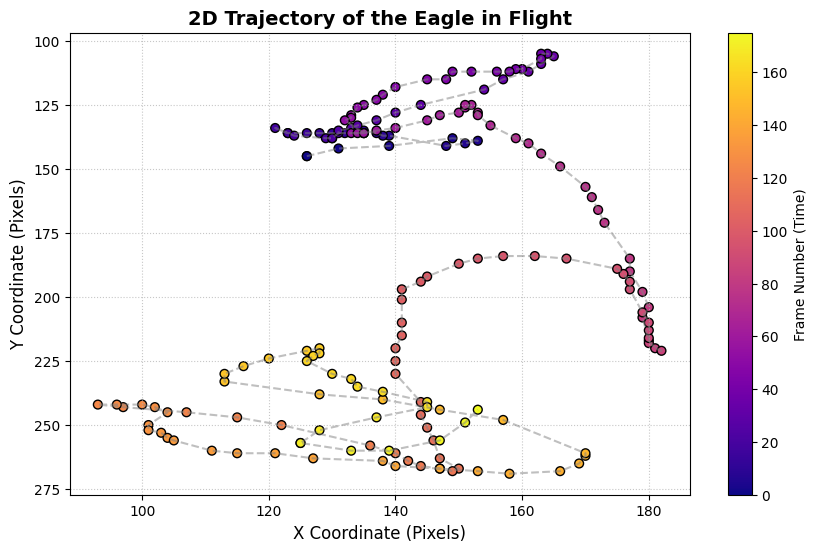

In [ ]:

import matplotlib.pyplot as plt
import numpy as np

output_plot_path = '/content/drive/My Drive/DIP_FinalProject/Eagle_Trajectory_Plot.png'

if len(centroids_x) > 0:
    plt.figure(figsize=(10, 6))


    times = np.arange(len(centroids_x))
    scatter = plt.scatter(centroids_x, centroids_y, c=times, cmap='plasma', marker='o', s=40, edgecolor='k')

    cbar = plt.colorbar(scatter)
    cbar.set_label('Frame Number (Time)')


    plt.plot(centroids_x, centroids_y, color='gray', linestyle='--', alpha=0.5)

    plt.title('2D Trajectory of the Eagle in Flight', fontsize=14, fontweight='bold')
    plt.xlabel('X Coordinate (Pixels)', fontsize=12)
    plt.ylabel('Y Coordinate (Pixels)', fontsize=12)

    plt.gca().invert_yaxis()
    plt.grid(True, linestyle=':', alpha=0.7)

    plt.savefig(output_plot_path, dpi=300, bbox_inches='tight')
    print(f"نمودار مسیر حرکت ذخیره شد:\n{output_plot_path}")
    plt.show()
else:
    print(" هیچ مسیری یافت نشد. به نظر می‌رسد مدل نتوانسته شیء را در ویدیو شناسایی کند.")